In [1]:
# import all necessary libraries

import os
import sys
sys.path.append('/home/mingdayang/FeatureBridgeMapping')
# os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import torch
from torch import nn
import torchvision
import numpy as np
import einops

import matplotlib.pyplot as plt
print(torch.__version__)
from data.dataset import BEVFeaturesDataset

from mmdet.models import HEADS
from mmdet3d.unibev_plugin.models.dense_heads import bev_consumer


1.10.0


In [2]:
gamma = 2
t = torch.tensor([0.1, 0.3, 0.65])  # weight for different std value regions
weight_map = t
stable_weight = torch.pow(weight_map, gamma)
print(stable_weight*10)
print(20*(t / torch.mean(t)))

tensor([0.1000, 0.9000, 4.2250])
tensor([ 5.7143, 17.1429, 37.1429])


In [2]:
device_number = 3
device = torch.device(f"cuda:{device_number}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:3


In [3]:
# Code for looking up nuscene
from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval
from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val
from nuscenes.nuscenes import NuScenes
data_root = '/home/mingdayang/mmdetection3d/data/nuscenes/'
nusc = NuScenes(version='v1.0-mini', dataroot=data_root, verbose=True)
eval_set = 'mini_val'
eval_detect_configs = config_factory('detection_cvpr_2019')

def find_sample_token(lidar_folder):
    print(lidar_folder.split('__'))
    timestamp_str = lidar_folder.split('__')[-1]
    print(timestamp_str)
    target_timestamp = int(timestamp_str)
    print(target_timestamp)

    # Initialize variables to track the closest sample
    closest_sample_token = None
    closest_time_diff = float('inf')

    # Iterate through all scenes
    for scene in nusc.scene:
        # Start from the first sample of the scene
        current_sample_token = scene['first_sample_token']

        while current_sample_token:
            # Retrieve the sample
            sample = nusc.get('sample', current_sample_token)

            # Calculate the time difference between the sample and the target timestamp
            time_diff = abs(sample['timestamp'] - target_timestamp)

            # Check for an exact match
            if sample['timestamp'] == target_timestamp:
                closest_sample_token = current_sample_token
                closest_time_diff = 0
                break

            # Update closest sample if this sample is closer
            if time_diff < closest_time_diff:
                closest_sample_token = current_sample_token
                closest_time_diff = time_diff

            # Move to the next sample in the scene
            current_sample_token = sample['next']

        # Break if we found an exact match
        if closest_time_diff == 0:
            break

    # Output the closest sample token and time difference
    if closest_sample_token:
        print(f"Closest sample token: {closest_sample_token}")
        print(f"Time difference (microseconds): {closest_time_diff}")
    else:
        print("No matching sample token found.")

    sample_token=closest_sample_token
    return sample_token

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.722 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [3]:
# Load the saved data from .pt files
# These files contain the BEV embeddings for images and point clouds from mini_nuscenes dataset generated through UniBEV model
all_img = torch.load('/home/mingdayang/mmdetection3d/mapping_test/all_img_bev.pt')
all_pts = torch.load('/home/mingdayang/mmdetection3d/mapping_test/all_pts_bev.pt')

X_test_mini = all_img["img_bev_embed"]
y_test_mini = all_pts["pts_bev_embed"]
print("all_img shape:", all_img["img_bev_embed"].shape, "all_pts shape:", all_pts["pts_bev_embed"].shape)
print("all_img dtype:", all_img["img_bev_embed"].dtype, "all_pts dtype:", all_pts["pts_bev_embed"].dtype)
print("all_img keys:", all_img.keys(), "all_pts keys:", all_pts.keys())
print("all_img device:", all_img["img_bev_embed"].device, "all_pts device:", all_pts["pts_bev_embed"].device)



one_sample_training = torch.load('/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_cnw_256_one_sample_mininuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951/vis_data.pt')
X_test_one = one_sample_training["img_bev_embed"]
y_test_one = one_sample_training["pts_bev_embed"]
print("one_sample_img shape:", X_test_one.shape, "one_sample_pts shape:", y_test_one.shape)
print("one_sample_img dtype:", X_test_one.dtype, "one_sample_pts dtype:", y_test_one.dtype)

all_img shape: torch.Size([81, 40000, 256]) all_pts shape: torch.Size([81, 40000, 256])
all_img dtype: torch.float32 all_pts dtype: torch.float32
all_img keys: dict_keys(['img_bev_embed', 'lidar_file_name']) all_pts keys: dict_keys(['pts_bev_embed', 'lidar_file_name'])
all_img device: cpu all_pts device: cpu
one_sample_img shape: torch.Size([1, 40000, 256]) one_sample_pts shape: torch.Size([1, 40000, 256])
one_sample_img dtype: torch.float32 one_sample_pts dtype: torch.float32


In [4]:
# Select sample to work with
X_test = einops.rearrange(X_test_mini, 'b (h w) c -> b c h w', w=200, h=200)
y_test = einops.rearrange(y_test_mini, 'b (h w) c -> b c h w', w=200, h=200)

print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

X_test shape: torch.Size([81, 256, 200, 200]) y_test shape: torch.Size([81, 256, 200, 200])


In [34]:
# Load a specific sample and visualize ground truth LiDAR BEV
sample_token = find_sample_token(all_img['lidar_file_name'][0])
sample = nusc.get('sample', sample_token)

nusc.render_sample_data(sample['data']['LIDAR_TOP'])


NameError: name 'find_sample_token' is not defined

In [3]:
# Define helper function to go between data formats
# from [Batch, Channels, Height, Width] to [Batch, Values, Channels]
import numpy as np

def bvc_to_bchw(tensor, H=200, W=200):
    """
    Convert [B, V, C] -> [B, C, H, W].
    Accepts torch.Tensor or numpy.ndarray. If H and W don't match V, will try to infer square side.
    """
    B, V, C = tensor.shape
    if V != H*W:
        raise ValueError(f"H and W are not product from V, please specify what H and W you want")
    
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, H, W, C)
        tensor = tensor.permute(0, 3, 2, 1).contiguous()
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, H, W, C)
        tensor = np.transpose(tensor, (0, 3, 2, 1))
        return tensor
    else:
        raise TypeError("Expected torch.TEnsor or numpy.ndarray")
    
def bchw_to_bvc(tensor):
    """
    Convert [B, C, H, W] -> [B, V, C] where V = H*W.
    Accepts torch.Tensor or numpy.ndarray.
    """
    B, C, H, W = tensor.shape
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, C, H*W)
        tensor = tensor.permute(0, 2, 1).contiguous()  
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, C, H*W)
        tensor = np.transpose(tensor, (0, 2, 1))
        return tensor



In [7]:
# Test out functions
img_bev_bchw = bvc_to_bchw(all_img["img_bev_embed"])
pts_bev_bchw = bvc_to_bchw(all_pts["pts_bev_embed"])
print("img_bev_bchw shape:", img_bev_bchw.shape, "pts_bev_bchw shape:", pts_bev_bchw.shape)

img_bev_bchw shape: torch.Size([81, 256, 200, 200]) pts_bev_bchw shape: torch.Size([81, 256, 200, 200])


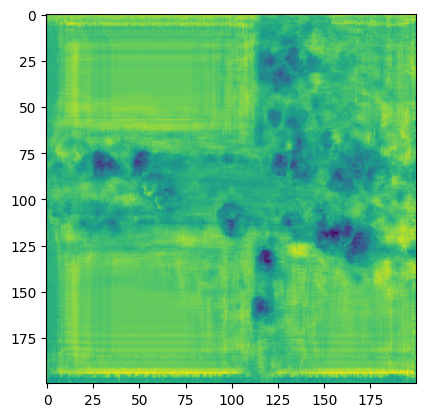

In [7]:
# visualize one channel to confirm it is loaded correctly
plt.imshow(bvc_to_bchw(all_pts["pts_bev_embed"])[0, 0].cpu().numpy())

Okay!! So we can see that the feature maps are also in the right orientation. Great!

# Data exploration


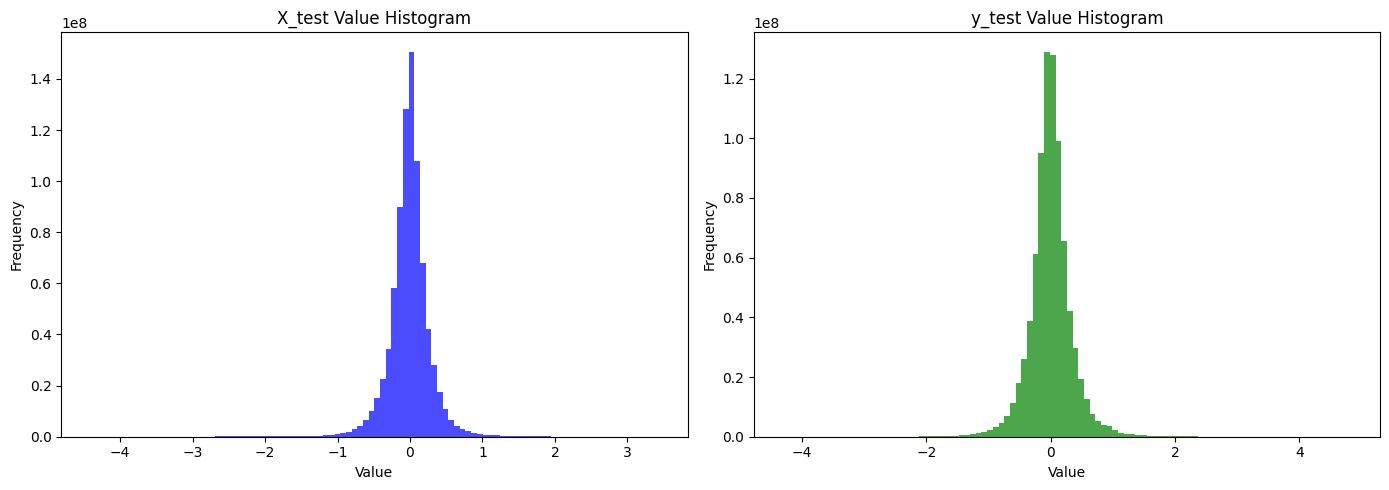

X_test - Min: -4.419580, Max: 3.436940, Mean: -0.010115, Std: 0.299756
y_test - Min: -4.316016, Max: 4.840936, Mean: 0.000723, Std: 0.348317


In [18]:
# Plot value histograms of X_test and y_test
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

X_test_np = X_test.cpu().numpy().flatten()
y_test_np = y_test.cpu().numpy().flatten()

axs[0].hist(X_test_np, bins=100, alpha=0.7, color='blue')
axs[0].set_title('X_test Value Histogram')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Frequency')

axs[1].hist(y_test_np, bins=100, alpha=0.7, color='green')
axs[1].set_title('y_test Value Histogram')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print statistics
print(f"X_test - Min: {X_test.min().item():.6f}, Max: {X_test.max().item():.6f}, Mean: {X_test.mean().item():.6f}, Std: {X_test.std().item():.6f}")
print(f"y_test - Min: {y_test.min().item():.6f}, Max: {y_test.max().item():.6f}, Mean: {y_test.mean().item():.6f}, Std: {y_test.std().item():.6f}")

# Model evaluation on mini nuscenes

In [4]:
# Load the feature mapping model.

l1_only = '/home/mingdayang/mmdetection3d/outputs/train/30012026001_UnetConcatenated_mini_nuscenes_infos_temporal_train_mini_nuscenes_infos_temporal_val_testing_viability_only_l1_loss/model_only.pth'
std_weight_higher = '/home/mingdayang/mmdetection3d/outputs/train/30012026003_UnetConcatenated_mini_nuscenes_infos_temporal_train_mini_nuscenes_infos_temporal_val_testing_viability_weighted_std_map_l1_loss_higher_stdweight/model_only.pth'
std_weight_msssim = '/home/mingdayang/mmdetection3d/outputs/train/31012026003_UnetConcatenated_mini_nuscenes_infos_temporal_train_mini_nuscenes_infos_temporal_val_testing_viability_l1_msssim_std_weight/model_only.pth'
unet_attention = '/home/mingdayang/mmdetection3d/outputs/train/02022026002_UNetAttention_mini_nuscenes_infos_temporal_train_mini_nuscenes_infos_temporal_val_msssim_l1_powerSTDweightmap/model_only.pth'
unet_atetntion_overfit = '/home/mingdayang/mmdetection3d/mapping_test/models/UNetAttention/UNetAttention_model_epoch280.pth'
unet_full_nuscenes = '/home/mingdayang/mmdetection3d/outputs/train/02022026003_UNetAttention_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_train_long/model_only_epoch_16.pth'
diffusion = '/home/mingdayang/FeatureBridgeMapping/checkpoints/25-02-2026-01_100_epoch_normal_forward.pth'

checkpoint = torch.load(diffusion)

print(checkpoint.keys())
# print(checkpoint['model_type'])
ModelClass = HEADS.get('DenoiseDiffusion')
print("ModelClass:", ModelClass, "type:", type(ModelClass))
print("Model config:", checkpoint['model_config'])
# print(checkpoint['model_config'].keys())
# checkpoint['model_config'].pop('msssim')
# checkpoint['model_config'].pop('std')
# checkpoint['model_config'].pop('gamma', None)

print("ModelClass accepted config keys:", ModelClass.__init__.__code__.co_varnames)
# for k, v in checkpoint['model_config'].items():
#     print(k, ":", v)
# print(checkpoint['model_config']['loss_config'])
# checkpoint['model_config'].pop('reduction')
# checkpoint['model_config'].pop('loss_config', None)
# checkpoint['model_config']['loss_config'] = None

# print(checkpoint)
model = ModelClass(model_config=checkpoint['model_config'], diffusion_config=checkpoint['diffusion_config'])
model.eps_model.load_state_dict(checkpoint['model_state_dict'])
print("Model loaded successfully.")
print("         Model info          ")
print("-----------------------------")
# print(model)
# print(vars(model))

dict_keys(['model_state_dict', 'model_config', 'diffusion_config', 'rolling_stats_img', 'rolling_stats_pts'])
ModelClass: <class 'mmdet3d.unibev_plugin.models.dense_heads.diffusion_model.DenoiseDiffusion'> type: <class 'abc.ABCMeta'>
Model config: {'in_channel': 6, 'out_channel': 3, 'inner_channel': 64, 'norm_groups': 32, 'channel_mults': (1, 2, 4, 8), 'attn_res': (25,), 'res_blocks': 2, 'dropout': 0, 'with_noise_level_emb': True, 'image_size': 200, 'eps': 1e-05}
ModelClass accepted config keys: ('self', 'model_config', 'diffusion_config')
Model loaded successfully.
         Model info          
-----------------------------


In [7]:
# ModelClass = HEADS.get('UnetPadDeeper')
# model = ModelClass()
# model.to(device)

In [5]:
model.set_new_noise_schedule(phase='test')

model.eval()
model.to(device)



DenoiseDiffusion(
  (loss_fn): L1Loss()
  (eps_model): UNet(
    (noise_level_mlp): Sequential(
      (0): PositionalEncoding()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): Swish()
      (3): Linear(in_features=256, out_features=64, bias=True)
    )
    (downs): ModuleList(
      (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ResnetBlocWithAttn(
        (res_block): ResnetBlock(
          (noise_func): FeatureWiseAffine(
            (noise_func): Sequential(
              (0): Linear(in_features=64, out_features=64, bias=True)
            )
          )
          (block1): Block(
            (block): Sequential(
              (0): GroupNorm(32, 64, eps=1e-05, affine=True)
              (1): Swish()
              (2): Identity()
              (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
          )
          (block2): Block(
            (block): Sequential(
              (0): GroupNorm(

In [12]:
from torchinfo import summary
X_test_device = X_test[:1].to(device)
summary(model, input_data=X_test_device)

Layer (type:depth-idx)                   Output Shape              Param #
UNetAttention                            [1, 40000, 256]           --
├─EncoderBlock: 1-1                      [1, 256, 200, 200]        --
│    └─ConvBlock: 2-1                    [1, 256, 200, 200]        --
│    │    └─Sequential: 3-1              [1, 256, 200, 200]        1,181,184
│    └─MaxPool2d: 2-2                    [1, 256, 100, 100]        --
├─EncoderBlock: 1-2                      [1, 512, 100, 100]        --
│    └─ConvBlock: 2-3                    [1, 512, 100, 100]        --
│    │    └─Sequential: 3-2              [1, 512, 100, 100]        3,542,016
│    └─MaxPool2d: 2-4                    [1, 512, 50, 50]          --
├─EncoderBlock: 1-3                      [1, 1024, 50, 50]         --
│    └─ConvBlock: 2-5                    [1, 1024, 50, 50]         --
│    │    └─Sequential: 3-3              [1, 1024, 50, 50]         14,161,920
│    └─MaxPool2d: 2-6                    [1, 1024, 25, 25]     

In [6]:
from torch.utils.data import DataLoader, Dataset
def make_loader(batch_size, dataset):

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        # Let's check out what we've created

    return dataloader

gen = torch.Generator()
gen.manual_seed(0)
train_split = 0.8
dataset = BEVFeaturesDataset(root_dir='/home/mingdayang/FeatureBridgeMapping/data/bev_features', transform=None)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [int(train_split * len(dataset)), len(dataset) - int(train_split * len(dataset))], generator=gen)
train_loader = make_loader(1, train_dataset)
test_loader = make_loader(1, test_dataset)

In [25]:
X_test = test_loader.dataset[0]['img_bev_embed'].to(device).unsqueeze(0)
print(X_test.shape)
y_test = test_loader.dataset[0]['pts_bev_embed'].to(device).unsqueeze(0)
y_pred, _ = model.ddpm_sampler(y_cond=model.rolling_stats_img.normalize(X_test))
y_pred = model.rolling_stats_pts.denormalize(y_pred)

torch.Size([1, 3, 200, 200])


DDPM sampler: 100%|██████████| 1000/1000 [00:26<00:00, 38.22it/s]


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

BATCH_INFER = 1  # pick a size that fits memory

infer_loader = DataLoader(
    TensorDataset(X_test),
    batch_size=BATCH_INFER,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

pred_chunks = []
with torch.inference_mode():
    for (xb,) in infer_loader:
        xb = xb.to(device, non_blocking=True).contiguous()
        yb,_ = model.ddpm_sampler(y_cond=xb)
        pred_chunks.append(yb.cpu())  # keep outputs on CPU to save GPU memory
        del xb, yb
        torch.cuda.empty_cache()
y_pred = torch.cat(pred_chunks,dim=0)

In [26]:
# y_pred = model(X_test_one.to(device)).detach().cpu()
X_test = X_test.cpu()
y_test = y_test.cpu()
y_pred = y_pred.cpu()
# X_test_one = X_test_one.cpu()
# y_test_one = y_test_one.cpu()

In [19]:
print(f"y_pred shape: {y_pred.shape}, y_test shape: {y_test.shape}")
print(f"X_test device: {X_test.device}, y_pred device: {y_pred.device}, y_test device: {y_test.device}")

y_pred shape: torch.Size([81, 256, 200, 200]), y_test shape: torch.Size([81, 256, 200, 200])
X_test device: cpu, y_pred device: cpu, y_test device: cpu


In [20]:
# Check if predictions have low variance compared to ground truth
print(f"Prediction std: {y_pred.std().item():.6f}")
print(f"Ground truth std: {y_test.std().item():.6f}")
print(f"Prediction range: [{y_pred.min().item():.4f}, {y_pred.max().item():.4f}]")
print(f"GT range: [{y_test.min().item():.4f}, {y_test.max().item():.4f}]")

# If pred_std << gt_std, the model learned to output the mean

Prediction std: 0.504173
Ground truth std: 0.348317
Prediction range: [-1.0000, 1.0000]
GT range: [-4.3160, 4.8409]


In [32]:
def plot_train_pred_test(X, y, y_pred, channel=0):
    fig, axs = plt.subplots(1, 3, figsize=(18,6))

    # Ensure all inputs are numpy arrays
    X_np = X[channel,:,:].cpu().numpy() if torch.is_tensor(X) else X[0,:,:]
    y_np = y[channel,:,:].cpu().numpy() if torch.is_tensor(y) else y[0,:,:]
    y_pred_np = y_pred[channel,:,:].cpu().numpy() if torch.is_tensor(y_pred) else y_pred[0,:,:]
    
    # Calculate shared color scale ONLY between predictions
    vmin = min(np.min(y_np), np.min(y_pred_np), np.min(X_np))
    vmax = max(np.max(y_np), np.max(y_pred_np), np.max(X_np))
    
    # im0 = axs[0].imshow(X_np, cmap='viridis', vmin=vmin, vmax=vmax)
    im0 = axs[0].imshow(X_np, cmap='viridis')
    axs[0].set_title("Input Image Feature Map")
    
    im1 = axs[1].imshow(y_np, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[1].set_title("Ground Truth LiDAR Feature Map")
    
    im2 = axs[2].imshow(y_pred_np, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[2].set_title("Predicted LiDAR Feature Map")
    
    # Add shared colorbar
    pos_right = axs[2].get_position()
    cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])
    fig.colorbar(im2, cax=cbar_ax)
    
    # plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

def multiple_channels(X, y, y_pred, channels, scene=0, scaled=True, title=""):
    # Handle both single integer and range of channels
    if isinstance(channels, int):
        channel_list = list(range(channels))
    else:
        channel_list = list(channels)
    
    num_channels = len(channel_list)
    fig, axs = plt.subplots(num_channels, 3, figsize=(12, 3.5 * num_channels))

    # Add title to the figure if provided
    if title:
        fig.suptitle(title, fontsize=14, y=0.995)

    # Handle case where there's only one channel (axs won't be 2D)
    if num_channels == 1:
        axs = axs.reshape(1, -1)

    for i, channel in enumerate(channel_list):
        # Ensure all inputs are numpy arrays
        X_np = X[scene,channel,:,:].cpu().numpy() if torch.is_tensor(X) else X[scene,channel,:,:]
        y_np = y[scene,channel,:,:].cpu().numpy() if torch.is_tensor(y) else y[scene,channel,:,:]
        y_pred_np = y_pred[scene,channel,:,:].cpu().numpy() if torch.is_tensor(y_pred) else y_pred[scene,channel,:,:]
        
        # Calculate shared color scale only if scaled is True
        if scaled:
            vmin = min(np.min(y_np), np.min(y_pred_np), np.min(X_np))
            vmax = max(np.max(y_np), np.max(y_pred_np), np.max(X_np))
        else:
            vmin = vmax = None
        
        axs[i, 0].imshow(X_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 0].set_title(f"Ch{channel} Sc{scene} - Input", fontsize=9)
        
        axs[i, 1].imshow(y_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 1].set_title(f"Ch{channel} Sc{scene} - GT LiDAR", fontsize=9)
        
        im2 = axs[i, 2].imshow(y_pred_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 2].set_title(f"Ch{channel} Sc{scene} - Pred LiDAR", fontsize=9)

        # Add shared colorbar for each row
        pos_right = axs[i, 2].get_position()
        cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])
        fig.colorbar(im2, cax=cbar_ax)
    
    plt.show()


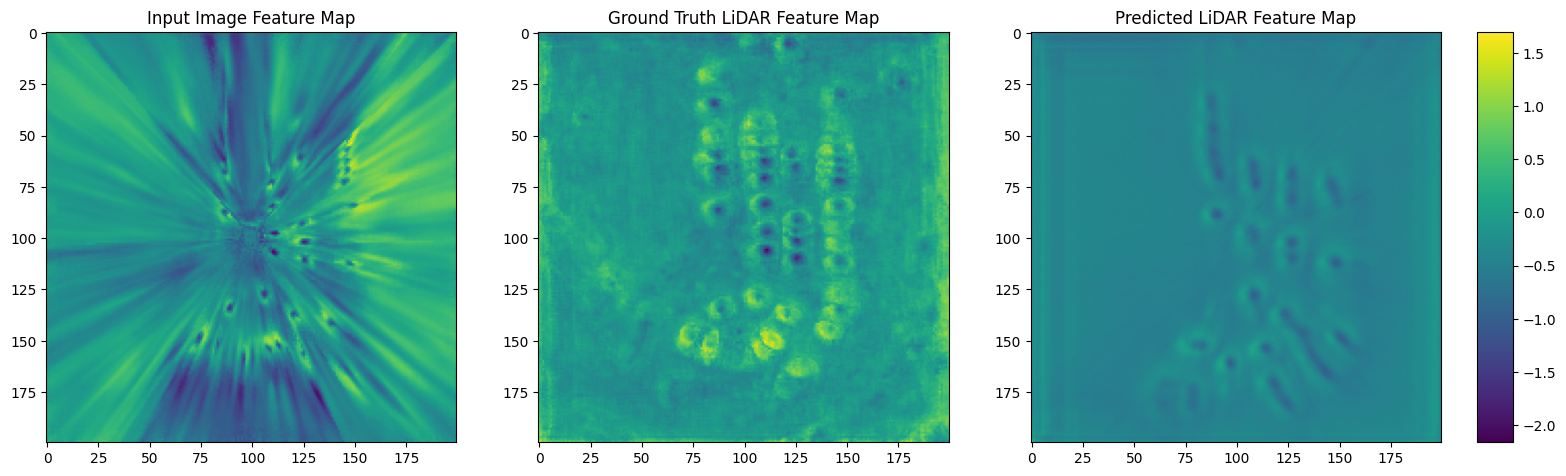

In [33]:
scene=0
channel=2
# plot_train_pred_test(bvc_to_bchw(X_test)[scene], bvc_to_bchw(y_test)[scene], bvc_
# to_bchw(y_pred)[scene], channel=channel)
plot_train_pred_test(X_test[scene], y_test[scene], (y_pred)[scene], channel=channel)

In [26]:
multiple_channels(bvc_to_bchw(X_test), bvc_to_bchw(y_test), bvc_to_bchw(y_pred), channels=range(20,23), scene=scene, scaled=True)

ValueError: too many values to unpack (expected 3)

# Feature analysis
So now we will produce some results that are meaningful and we can do something with. We want to showcase how well our model is. Our goal is representation similarity, not reconstruction in pixel space.

"Do the predicted features preserve structure, saliency, and information content of LiDAR BEV features?"

# MSE evaluation

Using torch function to calculate total MSE loss is basically

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y_i} - y_i)^2
$$

when using reduction = mean. It automatically calculates the average loss. 

In [34]:
def report_total_mse(prediction, ground_truth):
    """
    Calculate and report the Mean Squared Error (MSE) between prediction and ground truth tensors.
    
    Args:
        prediction: Predicted tensor [Any shape]
        ground_truth: Ground truth tensor [Any shape]
    return:
        mse_loss: Loss value (float) over all channels and samples
    """
    mse_loss_fn = nn.MSELoss()
    mse_loss = mse_loss_fn(prediction, ground_truth)
    print(f"Mean Squared Error (MSE) over all channels and samples: {mse_loss:.6f}")
    return mse_loss

def report_mse_sample(prediction, ground_truth):
    """
    Calculate MSE per sample and overage over channels
    
    
    Args:
        prediction: Predicted tensor [B, N, C]
        ground_truth: Ground truth tensor [B, N, C]

    Return:
        mse_per_sample: Tensor of shape [B, N] with MSE values per sample
    """

    mse_loss_fn = nn.MSELoss(reduction='none')
    mse_per_element = mse_loss_fn(prediction, ground_truth)  # Shape: [B, N, C]
    mse_per_sample = mse_per_element.mean(dim=1)  # Average over channels, shape: [B, N]
    print(f"MSE per pixel shape: {mse_per_sample.shape}")
    print(f"MSE per pixel min: {mse_per_sample.min().item():.6f}, max: {mse_per_sample.max().item():.6f}, mean: {mse_per_sample.mean().item():.6f}")
    return mse_per_sample

def visualize_mse_heatmap(mse_per_sample, scene=0):
    """
    Visualize MSE heatmap for a specific scene.
    
    Args:
        mse_per_sample: Tensor of shape [B, N] with MSE values per sample
        scene: Scene index to visualize
    """
    mse_scene = mse_per_sample[scene].cpu().numpy()  # Reshape to HxW
    plt.figure(figsize=(8, 6))
    plt.imshow(mse_scene, cmap='hot')
    plt.colorbar(label='MSE Value')
    plt.title(f'MSE Heatmap for Scene {scene}')
    plt.show()


Mean Squared Error (MSE) over all channels and samples: 0.216901
MSE per pixel shape: torch.Size([1, 200, 200])
MSE per pixel min: 0.009535, max: 1.977506, mean: 0.216901


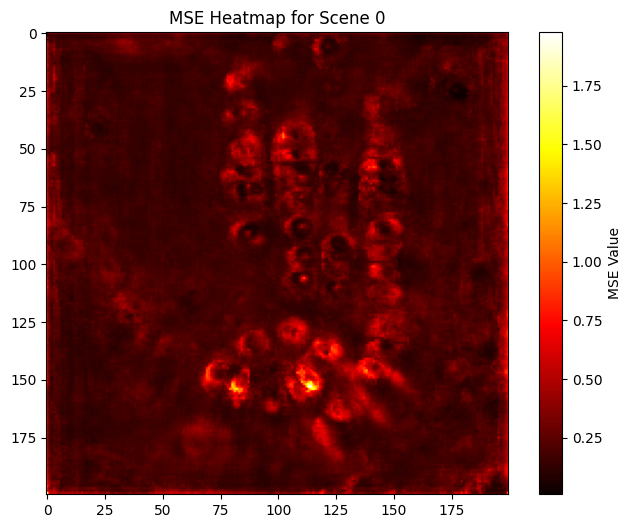

In [36]:
# Calculate MSE loss between predicted and ground truth
total_mse_loss = report_total_mse(y_pred, y_test)

# Per-pixel MSE map for visualization
mse_per_sample = report_mse_sample(y_pred, y_test)

visualize_mse_heatmap(mse_per_sample, scene=scene)

L1 Loss over all channels and samples: 0.424708
L1 per pixel shape: torch.Size([1, 200, 200])
L1 per pixel min: 0.082647, max: 1.295066, mean: 0.424708


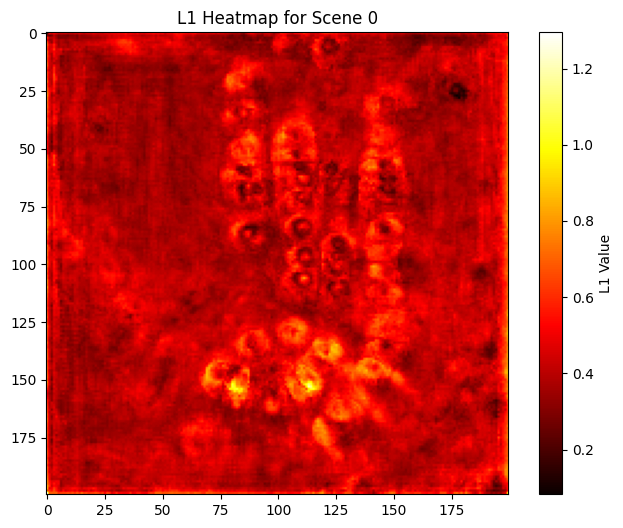

In [38]:
def report_total_l1(prediction, ground_truth):
    """
    Calculate and report the L1 Loss between prediction and ground truth tensors.
    
    Args:
        prediction: Predicted tensor [Any shape]
        ground_truth: Ground truth tensor [Any shape]
    return:
        l1_loss: Loss value (float) over all channels and samples
    """
    l1_loss_fn = nn.L1Loss()
    l1_loss = l1_loss_fn(prediction, ground_truth)
    print(f"L1 Loss over all channels and samples: {l1_loss:.6f}")
    return l1_loss

def report_l1_sample(prediction, ground_truth):
    """
    Calculate L1 per sample and average over channels
    
    Args:
        prediction: Predicted tensor [B, C, H, W]
        ground_truth: Ground truth tensor [B, C, H, W]

    Return:
        l1_per_sample: Tensor of shape [B, H, W] with L1 values per sample
    """
    l1_loss_fn = nn.L1Loss(reduction='none')
    l1_per_element = l1_loss_fn(prediction, ground_truth)  # Shape: [B, C, H, W]
    l1_per_sample = l1_per_element.mean(dim=1)  # Average over channels, shape: [B, H, W]
    print(f"L1 per pixel shape: {l1_per_sample.shape}")
    print(f"L1 per pixel min: {l1_per_sample.min().item():.6f}, max: {l1_per_sample.max().item():.6f}, mean: {l1_per_sample.mean().item():.6f}")
    return l1_per_sample

def visualize_l1_heatmap(l1_per_sample, scene=0):
    """
    Visualize L1 heatmap for a specific scene.
    
    Args:
        l1_per_sample: Tensor of shape [B, H, W] with L1 values per sample
        scene: Scene index to visualize
    """
    l1_scene = l1_per_sample[scene].cpu().numpy()
    plt.figure(figsize=(8, 6))
    plt.imshow(l1_scene, cmap='hot')
    plt.colorbar(label='L1 Value')
    plt.title(f'L1 Heatmap for Scene {scene}')
    plt.show()

# Calculate L1 loss between predicted and ground truth
total_l1_loss = report_total_l1((y_pred), (y_test))

# Per-pixel L1 map for visualization
l1_per_sample = report_l1_sample((y_pred), (y_test))

visualize_l1_heatmap(l1_per_sample, scene=scene)

In [36]:
# Calculate L1 loss per sample (averaged over spatial and channel dimensions)
l1_per_sample_list = []
for i in range(y_pred.shape[0]):
    l1_sample = nn.L1Loss()(y_pred[i], y_test[i])
    l1_per_sample_list.append(l1_sample.item())

l1_per_sample_tensor = torch.tensor(l1_per_sample_list)
print(f"L1 loss per sample: {l1_per_sample_tensor}")
print(f"Mean L1 loss: {l1_per_sample_tensor.mean():.6f}")
print(f"Min L1 loss: {l1_per_sample_tensor.min():.6f}, Max L1 loss: {l1_per_sample_tensor.max():.6f}")

L1 loss per sample: tensor([0.3039, 0.3155, 0.3177, 0.3228, 0.3193, 0.3089, 0.3157, 0.3204, 0.3270,
        0.3222, 0.3318, 0.3350, 0.3317, 0.3355, 0.3321, 0.3279, 0.3291, 0.3287,
        0.3230, 0.3242, 0.3256, 0.3244, 0.3258, 0.3311, 0.3345, 0.3311, 0.3341,
        0.3283, 0.3336, 0.3338, 0.3318, 0.3296, 0.3318, 0.3332, 0.3278, 0.3308,
        0.3293, 0.3238, 0.3219, 0.3245, 0.3120, 0.3208, 0.3189, 0.3205, 0.3210,
        0.3277, 0.3294, 0.3353, 0.3401, 0.3420, 0.3408, 0.3403, 0.3389, 0.3363,
        0.3343, 0.3410, 0.3412, 0.3394, 0.3420, 0.3364, 0.3388, 0.3347, 0.3369,
        0.3402, 0.3414, 0.3413, 0.3389, 0.3427, 0.3465, 0.3394, 0.3401, 0.3401,
        0.3326, 0.3324, 0.3351, 0.3358, 0.3354, 0.3385, 0.3432, 0.3410, 0.3433])
Mean L1 loss: 0.331304
Min L1 loss: 0.303927, Max L1 loss: 0.346488


# STD evaluation
### Channel-wise Standard Deviation of Feature Maps
### Channel-wise Standard Deviation of Feature Maps

Let a feature tensor be given as:

$$
\mathbf{F} \in \mathbb{R}^{H \times W \times C}
$$

At a fixed spatial location $(x, y)$, the network produces a feature vector across channels:

$$
\mathbf{f}(x,y) = \left[ f_1(x,y), f_2(x,y), \dots, f_C(x,y) \right]
$$

The **channel-wise mean activation** at that location is defined as:

$$
\mu(x,y) = \frac{1}{C} \sum_{c=1}^{C} f_c(x,y)
$$

The **channel-wise standard deviation** is then computed as:

$$
\sigma(x,y) =
\sqrt{
\frac{1}{C}
\sum_{c=1}^{C}
\left( f_c(x,y) - \mu(x,y) \right)^2
}
$$

This statistic measures the **spread of feature activations across channels at each spatial location**.  
A higher value of $\sigma(x,y)$ indicates that individual channels deviate strongly from the mean activation, while a lower value indicates that channel activations are similar or redundant.


In [37]:
# y_pred, X_test and y_test all in (Batch, Values, Channel) format
print("y_pred shape:", y_pred.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

y_pred shape: torch.Size([81, 40000, 256])
X_test.shape: torch.Size([81, 40000, 256])
y_test.shape: torch.Size([81, 40000, 256])


In [39]:
# Calculating the std of the outputs
std_output_per_batch = torch.std((y_pred), dim=1)
std_output_test = torch.std((y_test), dim=1)
# std_output_test = torch.std(bvc_to_bchw(y_test), dim=1)
print(std_output_per_batch.shape)

torch.Size([1, 200, 200])


In [45]:
print(std_output_per_batch.mean().item())

0.619910478591919


In [40]:
def visualize_std(std_tensor, scene=0):
    """
    Visualize the standard deviation tensor as a heatmap.
    
    Args:
        std_tensor: Standard deviation tensor [B, C, H, W]
        scene: Scene index to visualize
    """
    std_scene = std_tensor[scene]
    
    fig, ax = plt.subplots(1, figsize=(8, 6))
    
    im = ax.imshow(std_scene, cmap='hot')
    ax.set_title(f"Scene {scene} - Std Heatmap (Averaged across Channels)")
    fig.colorbar(im, ax=ax, label='Standard Deviation')
    
    plt.show()

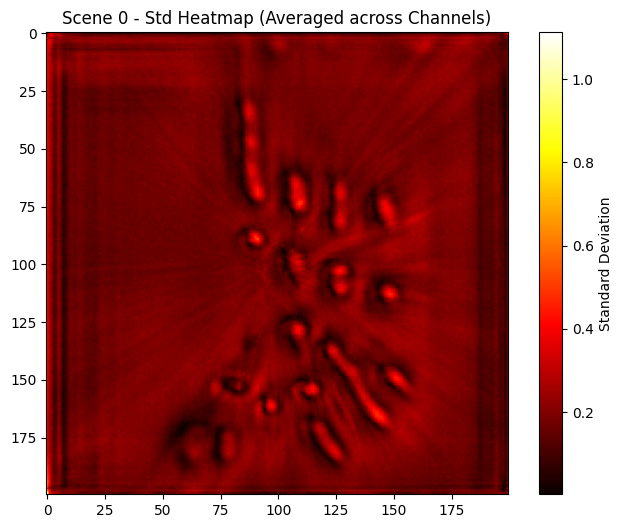

In [47]:
visualize_std(std_output_per_batch, scene=scene)

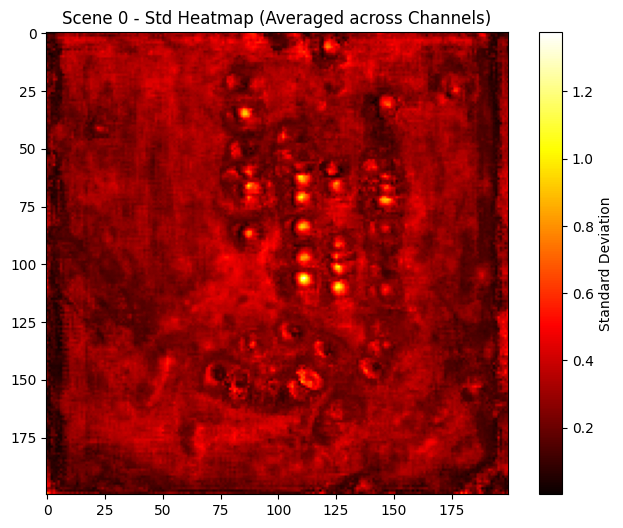

In [41]:
visualize_std(std_output_test, scene=scene)

# Cosine similarity


In [42]:
from torch.nn import CosineSimilarity

loss_fn = CosineSimilarity(dim=1, eps=1e-8)
print("y_pred.shape:", y_pred.shape, "y_test.shape:", y_test.shape)
cosine_similarities = loss_fn((y_pred), (y_test))
print("Cosine similarities shape:", cosine_similarities.shape)

y_pred.shape: torch.Size([1, 3, 200, 200]) y_test.shape: torch.Size([1, 3, 200, 200])
Cosine similarities shape: torch.Size([1, 200, 200])


In [43]:
def calculate_cosine_per_sample(prediction, ground_truth):    
    """
    Calculate Cosine Similarity per sample and average over all samples
    
    Args:
        prediction: Predicted tensor [B, C, H, W]
        ground_truth: Ground truth tensor [B, C, H, W]
    return:
        cosine_per_sample: Tensor of shape [B, H, W] with Cosine Similarity values per sample
    """
    cosine_loss_fn = CosineSimilarity(dim=1, eps=1e-8)
    cosine_per_sample = cosine_loss_fn(prediction, ground_truth)
    return cosine_per_sample

def calculate_total_cosine_similarity(cosine_per_sample):
    """
    Calculate the average Cosine Similarity between prediction and ground truth tensors over the channel dimension.
    Meaning the final output is a representation of how similary per pixel cosine is.
    
    Args:
        prediction: Predicted tensor [B, H, W]
        ground_truth: Ground truth tensor [B, H, W]
    Return:
        avg_cosine_similarity: Average Cosine Similarity (float) over all samples
    """
    cosine_average = cosine_per_sample.mean()
    return cosine_average



def report_cosine_similarity(prediction, ground_truth):
    """
    Calculate and report the average Cosine Similarity between prediction and ground truth tensors.
    
    Args:
        prediction: Predicted tensor [B, C, H, W]
        ground_truth: Ground truth tensor [B, C, H, W]
    return:
        avg_cosine_similarity: Average Cosine Similarity (float) over all samples
    """

    per_sample = calculate_cosine_per_sample(prediction, ground_truth)
    average = calculate_total_cosine_similarity(per_sample)

    print(f"Average Cosine Similarity over all samples: {average:.6f}")
    print(f"Cosine Similarity per pixel shape: {per_sample.shape}")
    print(f"Cosine Similarity per pixel min: {per_sample.min().item():.6f}, max: {per_sample.max().item():.6f}, mean: {per_sample.mean().item():.6f}")

    return average, per_sample


def visualize_cosine(tensor, scene=0):
    """
    Visualize the cosine similarity as a heatmap
    
    Args:
        tensor: tensor [B, H, W]
        scene: Scene index to visualize
    """
    scene_map = tensor[scene]
    
    fig, ax = plt.subplots(1, figsize=(8, 6))
    
    im = ax.imshow(scene_map, cmap='hot')
    ax.set_title(f"Scene {scene} - Cosine similarity Heatmap")
    fig.colorbar(im, ax=ax)
    
    plt.show()

Average Cosine Similarity over all samples: -0.216991
Cosine Similarity per pixel shape: torch.Size([1, 200, 200])
Cosine Similarity per pixel min: -0.999954, max: 0.945332, mean: -0.216991


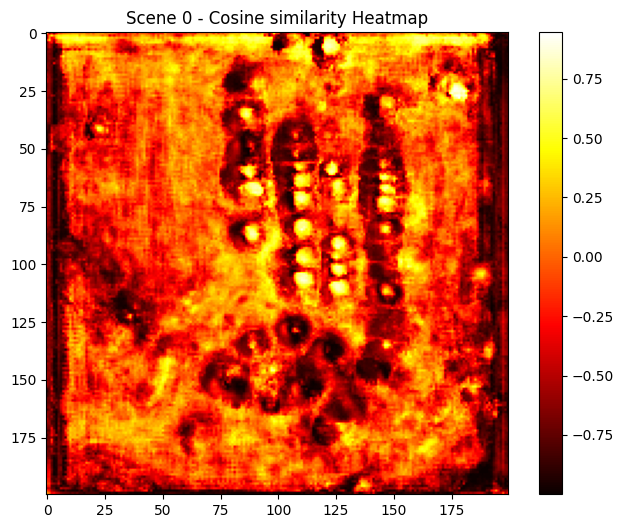

In [48]:
avg_cosine, cosine_per_sample = report_cosine_similarity((y_pred), (y_test))

visualize_cosine(cosine_per_sample, scene=scene)

Now we can also compute the cosine similarity of the std maps

Cosine similarities of std shape: torch.Size([1, 200, 200])


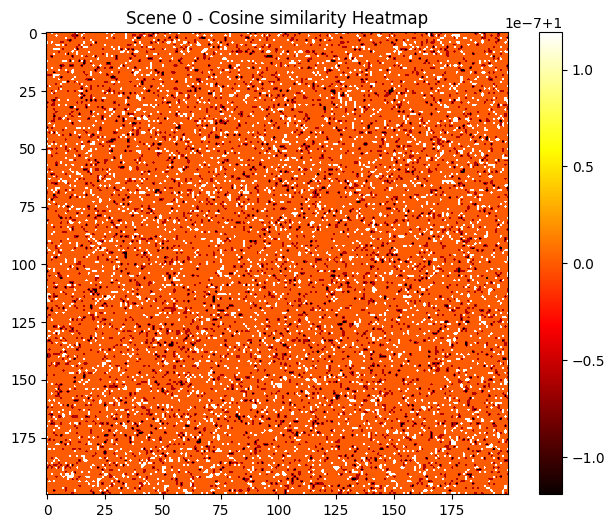

In [46]:
loss_fn_std = CosineSimilarity(dim=0, eps=1e-8)
cosine_std = loss_fn_std(std_output_per_batch, std_output_test)
cosine_std = cosine_std.unsqueeze(0)
print("Cosine similarities of std shape:", cosine_std.shape)
visualize_cosine(cosine_std, scene=scene)

In [44]:
# Calculate the mean cosine similarity between the two std maps
mean_cosine_std = cosine_std.mean().item()
print(f"Mean cosine similarity between std maps: {mean_cosine_std:.4f}")

Mean cosine similarity between std maps: 1.0000


# PCA-based visualization
Instead of pjer channel plots we will use pca to get a rgb plot

## PCA for qualitative spatial structure

In [18]:
from sklearn.decomposition import PCA
torch.manual_seed(42)


def shufflerow(tensor, axis):
    row_perm = torch.rand(tensor.shape[:axis+1]).argsort(axis)  # get permutation indices
    for _ in range(tensor.ndim-axis-1): row_perm.unsqueeze_(-1)
    row_perm = row_perm.repeat(*[1 for _ in range(axis+1)], *(tensor.shape[axis+1:]))  # reformat this for the gather operation
    return tensor.gather(axis, row_perm)

X_test = all_img['img_bev_embed']
y_test = all_pts['pts_bev_embed']

B, HW, C = y_test.shape
N = 0
n_components=0.95

X_test_flat = X_test.reshape(-1, C)      # if already tensor, keep as tensor for other ops
y_test_flat = y_test.reshape(-1, C)
y_pred_flat = y_pred.reshape(-1, C)

y_test_np = y_test_flat.cpu().numpy() if torch.is_tensor(y_test_flat) else y_test_flat
y_pred_np = y_pred_flat.cpu().numpy() if torch.is_tensor(y_pred_flat) else y_pred_flat
X_test_np = X_test_flat.cpu().numpy() if torch.is_tensor(X_test_flat) else X_test_flat

pca = PCA(n_components=n_components)
pca.fit(y_test_np)

N = pca.components_.shape[0]
print("PCA explained variance ratios:", pca.explained_variance_ratio_)
print("PCA components shape:", pca.components_.shape)
print("Amount of PCA components:", pca.components_.shape[0])

PCA explained variance ratios: [0.15914215 0.11556905 0.10241185 0.07563768 0.05651253 0.03835025
 0.0296466  0.0257249  0.02280446 0.02188165 0.01945859 0.01838682
 0.0179298  0.01634425 0.01613185 0.01494793 0.01324206 0.0126983
 0.01113828 0.01035974 0.0095842  0.00884114 0.00860363 0.00767734
 0.00749878 0.00712014 0.00656685 0.00585873 0.00545607 0.00513824
 0.0046497  0.00445945 0.00441941 0.00388936 0.003591   0.00349291
 0.00325679 0.0030552  0.00298204 0.00294149 0.00282446 0.00263342
 0.0025564  0.00250002 0.00234493 0.00218223 0.00206546 0.00201967
 0.00193741 0.00191681 0.0017865  0.00173998 0.00166933 0.00160254
 0.0015164  0.00147329 0.0014428  0.00142682 0.00135123 0.00130982
 0.00129976 0.00126584 0.00119212 0.00114067]
PCA components shape: (64, 256)
Amount of PCA components: 64


In [19]:
# ### sanity check
# print(y_pred[:,0])
# y_pred_shuffled = shufflerow(y_pred, 1)
# print(y_pred_shuffled[:,0])
# z_pred_shuffled = pca.transform(y_pred_shuffled).reshape(B, HW, N)
# ###

z_input = pca.transform(X_test_np)
z_test = pca.transform(y_test_np)
z_pred = pca.transform(y_pred_np)

print("z_input shape:", z_input.shape, "z_test shape:", z_test.shape, "z_pred shape:", z_pred.shape)

z_input = z_input.reshape(B, HW, N)
z_test = z_test.reshape(B, HW, N)
z_pred = z_pred.reshape(B, HW, N)
print("z_input reshaped shape:", z_input.shape, "z_test reshaped shape:", z_test.shape, "z_pred reshaped shape:", z_pred.shape)

z_input shape: (3240000, 64) z_test shape: (3240000, 64) z_pred shape: (3240000, 64)
z_input reshaped shape: (81, 40000, 64) z_test reshaped shape: (81, 40000, 64) z_pred reshaped shape: (81, 40000, 64)


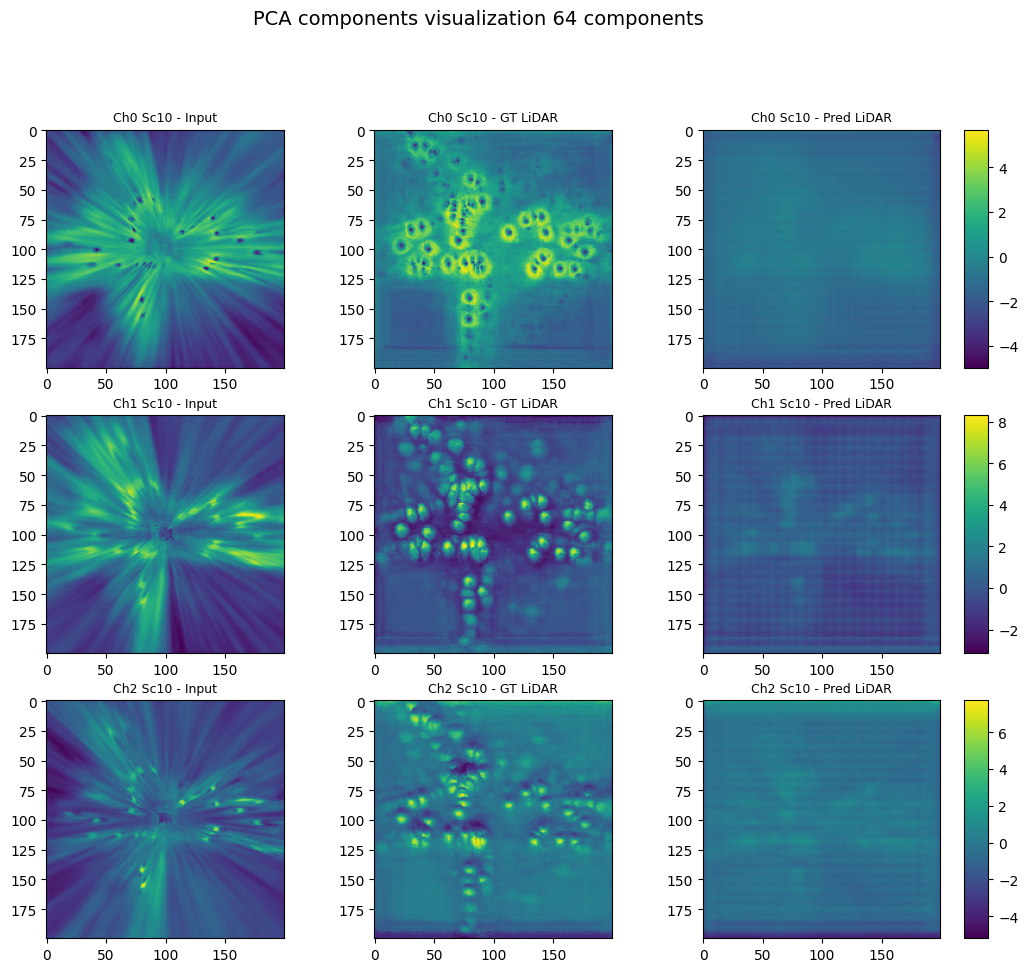

In [20]:
title = f"PCA components visualization {N} components"

multiple_channels(bvc_to_bchw(z_input), bvc_to_bchw(z_test), bvc_to_bchw(z_pred), channels=range(3), scene=10, scaled=True, title=title)

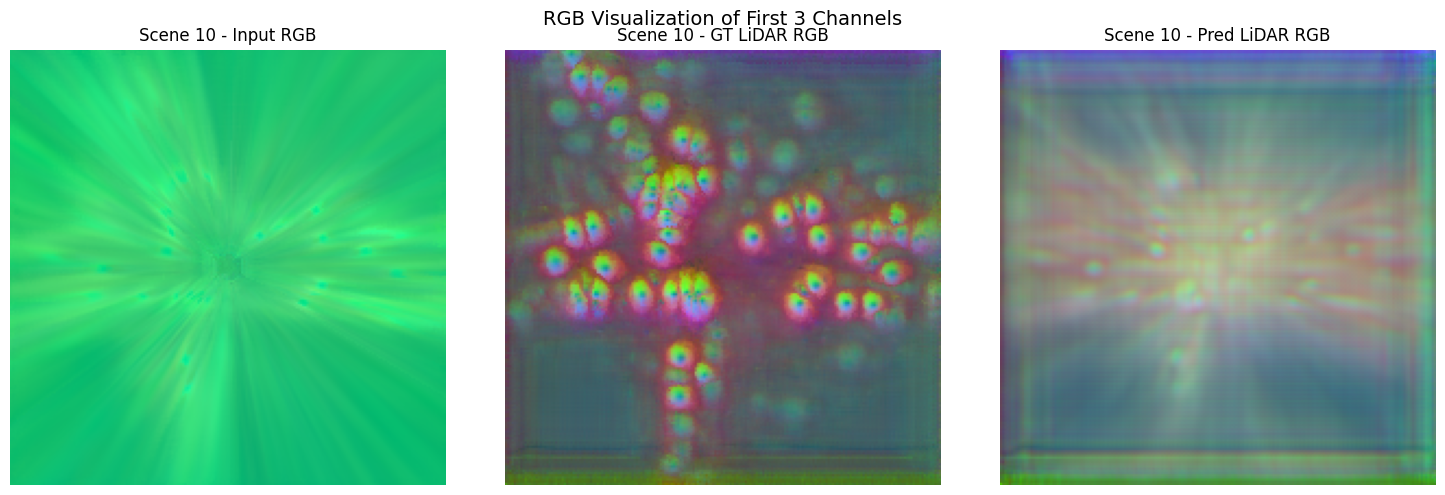

In [45]:
multiple_channels_rgb(bvc_to_bchw(z_input), bvc_to_bchw(z_test), bvc_to_bchw(z_pred), scene=10, title="RGB Visualization of First 3 Channels")

In [49]:
def visualize_empty(tensor_input, tensor_output, scene=0, channel=0):
    """
    Visualize two tensors side by side as heatmaps with shared color scale.
    
    Args:
        tensor_input: Input tensor [B, C, H, W]
        tensor_output: Output tensor [B, C, H, W]
        scene: Scene index to visualize
        channel: Channel index to visualize
    """
    input_map = tensor_input[scene, channel].cpu().numpy() if torch.is_tensor(tensor_input) else tensor_input[scene, channel]
    output_map = tensor_output[scene, channel].cpu().numpy() if torch.is_tensor(tensor_output) else tensor_output[scene, channel]
    
    # Calculate shared color scale
    vmin = min(input_map.min(), output_map.min())
    vmax = max(input_map.max(), output_map.max())
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    im0 = axs[0].imshow(input_map, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[0].set_title(f"Scene {scene} Ch {channel} - Input")
    
    im1 = axs[1].imshow(output_map, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[1].set_title(f"Scene {scene} Ch {channel} - Output")
    
    # Add shared colorbar
    fig.colorbar(im1, ax=axs, shrink=0.8)
    
    plt.show()

ones shape: torch.Size([81, 256, 200, 200]) zeros shape: torch.Size([81, 256, 200, 200])


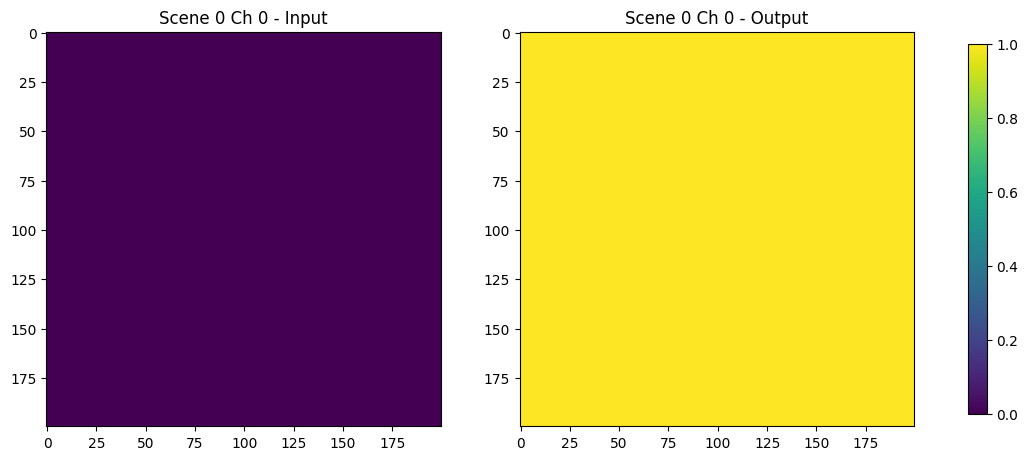

In [51]:
ones = torch.ones_like(bvc_to_bchw(y_pred))
zeros = torch.zeros_like(bvc_to_bchw(y_pred))
print("ones shape:", ones.shape, "zeros shape:", zeros.shape)
visualize_empty(zeros, ones)